# Week 7 Interim Submission - Random Forest Benchmark

**Student:** Vishal Baboolal  
**Project:** AI-Assisted Emergency Department Triage

This notebook reuses the Week 6 dataset, feature selection, test patients and `random_state=42`. It compares the Week 6 logistic-regression and decision-tree baselines with a Week 7 random forest.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
LABELS = [1, 2, 3, 4, 5]

print("Libraries loaded.")
print("Random seed:", RANDOM_STATE)

Libraries loaded.
Random seed: 42


## 1. Load the cleaned Week 5 dataset

The patient-level dataset is not committed to GitHub. In Google Colab, upload `data_cleaned_week5.csv` to `/content/` or place it in Google Drive.

In [2]:
candidate_paths = [
    Path("data_cleaned_week5.csv"),
    Path("../data/data_cleaned_week5.csv"),
    Path("/content/data_cleaned_week5.csv"),
    Path("/content/drive/MyDrive/data_cleaned_week5.csv"),
    Path("/mnt/data/data_cleaned_week5.csv"),
]

DATA_PATH = next(
    (path for path in candidate_paths if path.exists()),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Upload data_cleaned_week5.csv or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print(
    f"Loaded {df.shape[0]:,} patient visits and "
    f"{df.shape[1]} columns."
)
print("\nTarget distribution:")
print(df["esi"].value_counts().sort_index())

Loaded 55,121 patient visits and 225 columns.

Target distribution:
esi
1       77
2    17924
3    27010
4     8896
5     1214


## 2. Reuse the Week 6 feature selection

Post-triage leakage variables, administrative fields and fairness-sensitive demographic variables remain excluded from the clinical baseline.

In [3]:
TARGET = "esi"

DEMOGRAPHICS = [
    "age", "gender", "ethnicity", "race", "lang", "religion",
    "maritalstatus", "employstatus", "insurance_status",
]

ADMIN = [
    "dep_name", "arrivalmode", "arrivalmonth",
    "arrivalday", "arrivalhour_bin",
]

LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [
    column
    for column in df.columns
    if column != TARGET
    and column not in LEAKAGE + ADMIN + DEMOGRAPHICS
]

X = df[FEATURES]
y = df[TARGET]

print("Model features:", len(FEATURES))
print(
    "Missing values in model matrix:",
    int(X.isna().sum().sum()),
)
print(
    "All features numeric:",
    all(pd.api.types.is_numeric_dtype(X[c]) for c in X.columns),
)

Model features: 208
Missing values in model matrix: 0
All features numeric: True


## 3. Reproduce the exact Week 6 train/test split

The same 80/20 stratified split and `random_state=42` are used so the model comparison remains fair.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training records: {len(X_train):,}")
print(f"Testing records:  {len(X_test):,}")
print("\nTest-set class counts:")
print(y_test.value_counts().sort_index())

Training records: 44,096
Testing records:  11,025

Test-set class counts:
1      16
2    3585
3    5402
4    1779
5     243


## 4. Benchmark helper

For this multiclass and imbalanced problem, precision, recall and F1 are reported using macro averaging so each ESI class contributes equally. ESI Level 1 recall is also retained as a clinical safety measure.

In [5]:
def benchmark_row(
    name,
    predictions,
    training_seconds,
    inference_seconds,
    interpretability,
):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro Precision": precision_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "Macro Recall": recall_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "Macro F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "ESI 1 Recall": recall_score(
            y_test,
            predictions,
            labels=[1],
            average=None,
            zero_division=0,
        )[0],
        "Training Time (s)": training_seconds,
        "Inference Time per Prediction (ms)": (
            inference_seconds / len(X_test)
        ) * 1000,
        "Interpretability": interpretability,
    }

## 5. Week 6 logistic-regression baseline

Training time includes scaling and model fitting. Inference time includes scaling and prediction.

In [6]:
lr_training_start = time.perf_counter()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

logistic_regression = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
logistic_regression.fit(X_train_scaled, y_train)

lr_training_seconds = (
    time.perf_counter() - lr_training_start
)

lr_inference_start = time.perf_counter()

X_test_scaled = scaler.transform(X_test)
lr_predictions = logistic_regression.predict(X_test_scaled)

lr_inference_seconds = (
    time.perf_counter() - lr_inference_start
)

print(
    "Logistic-regression accuracy:",
    f"{accuracy_score(y_test, lr_predictions):.3f}",
)

Logistic-regression accuracy: 0.667


## 6. Week 6 bounded decision-tree baseline

In [7]:
tree = DecisionTreeClassifier(
    max_depth=12,
    random_state=RANDOM_STATE,
)

tree_training_start = time.perf_counter()
tree.fit(X_train, y_train)
tree_training_seconds = (
    time.perf_counter() - tree_training_start
)

tree_inference_start = time.perf_counter()
tree_predictions = tree.predict(X_test)
tree_inference_seconds = (
    time.perf_counter() - tree_inference_start
)

print(
    "Decision-tree accuracy:",
    f"{accuracy_score(y_test, tree_predictions):.3f}",
)

Decision-tree accuracy: 0.585


## 7. Week 7 complex model - Random Forest

The model uses 200 trees. `max_depth=20` and `min_samples_leaf=5` limit overfitting. Class balancing gives rare ESI classes more influence. `n_jobs=1` provides an auditable single-core timing benchmark.

In [8]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

rf_training_start = time.perf_counter()
random_forest.fit(X_train, y_train)
rf_training_seconds = (
    time.perf_counter() - rf_training_start
)

rf_inference_start = time.perf_counter()
rf_predictions = random_forest.predict(X_test)
rf_inference_seconds = (
    time.perf_counter() - rf_inference_start
)

print(
    "Random-forest accuracy:",
    f"{accuracy_score(y_test, rf_predictions):.3f}",
)
print(
    "Random-forest ESI 1 recall:",
    f"{recall_score(
        y_test,
        rf_predictions,
        labels=[1],
        average=None,
        zero_division=0,
    )[0]:.3f}",
)

Random-forest accuracy: 0.497
Random-forest ESI 1 recall: 0.500


## 8. Draft seven-axis benchmark

In [9]:
benchmark = pd.DataFrame(
    [
        benchmark_row(
            "Logistic Regression (Week 6)",
            lr_predictions,
            lr_training_seconds,
            lr_inference_seconds,
            "High",
        ),
        benchmark_row(
            "Decision Tree, max_depth=12 (Week 6)",
            tree_predictions,
            tree_training_seconds,
            tree_inference_seconds,
            "High",
        ),
        benchmark_row(
            "Random Forest, 200 trees (Week 7)",
            rf_predictions,
            rf_training_seconds,
            rf_inference_seconds,
            "Medium",
        ),
    ]
)

benchmark.round(4)

Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ESI 1 Recall,Training Time (s),Inference Time per Prediction (ms),Interpretability
Logistic Regression (Week 6),0.6668,0.5825,0.4630,0.4925,0.2500,14.0433,0.0096,High
"Decision Tree, max_depth=12 (Week 6)",0.5848,0.4806,0.2948,0.3027,0.0625,0.5671,0.0012,High
"Random Forest, 200 trees (Week 7)",0.4965,0.4074,0.5568,0.3984,0.5000,9.3241,0.0222,Medium


## 9. Random-forest per-class results

In [10]:
print(
    classification_report(
        y_test,
        rf_predictions,
        labels=LABELS,
        digits=3,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           1      0.143     0.500     0.222        16
           2      0.628     0.639     0.633      3585
           3      0.796     0.309     0.445      5402
           4      0.315     0.768     0.447      1779
           5      0.155     0.568     0.244       243

    accuracy                          0.497     11025
   macro avg      0.407     0.557     0.398     11025
weighted avg      0.649     0.497     0.502     11025


## 10. Random-forest confusion matrix

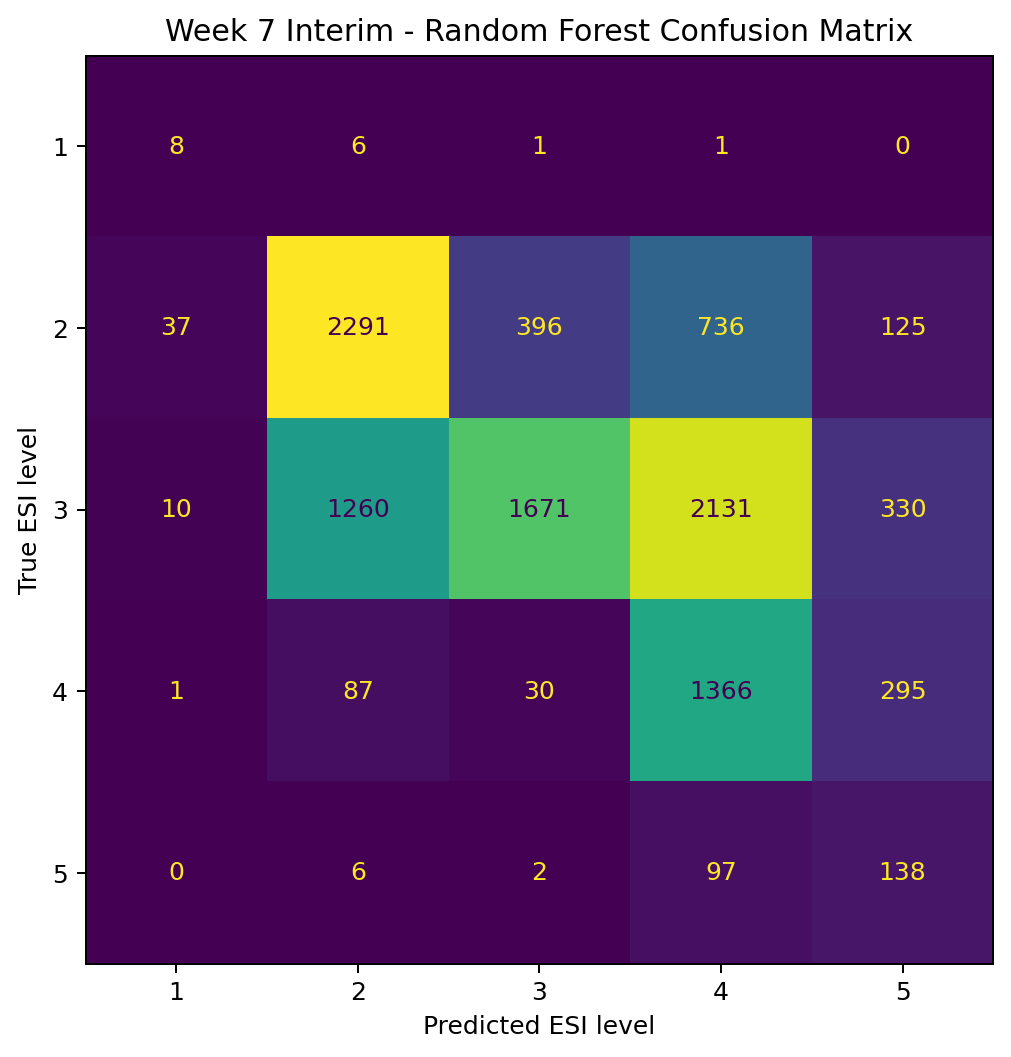

In [11]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=LABELS,
)

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=LABELS,
).plot(
    ax=ax,
    values_format="d",
    colorbar=False,
)

ax.set_title(
    "Week 7 Interim - Random Forest Confusion Matrix"
)
ax.set_xlabel("Predicted ESI level")
ax.set_ylabel("True ESI level")

plt.tight_layout()
plt.show()

## 11. Global feature importance

Feature importance gives a global view of which inputs influence the forest most. It does not fully explain one patient's prediction, which is why random-forest interpretability is rated medium.

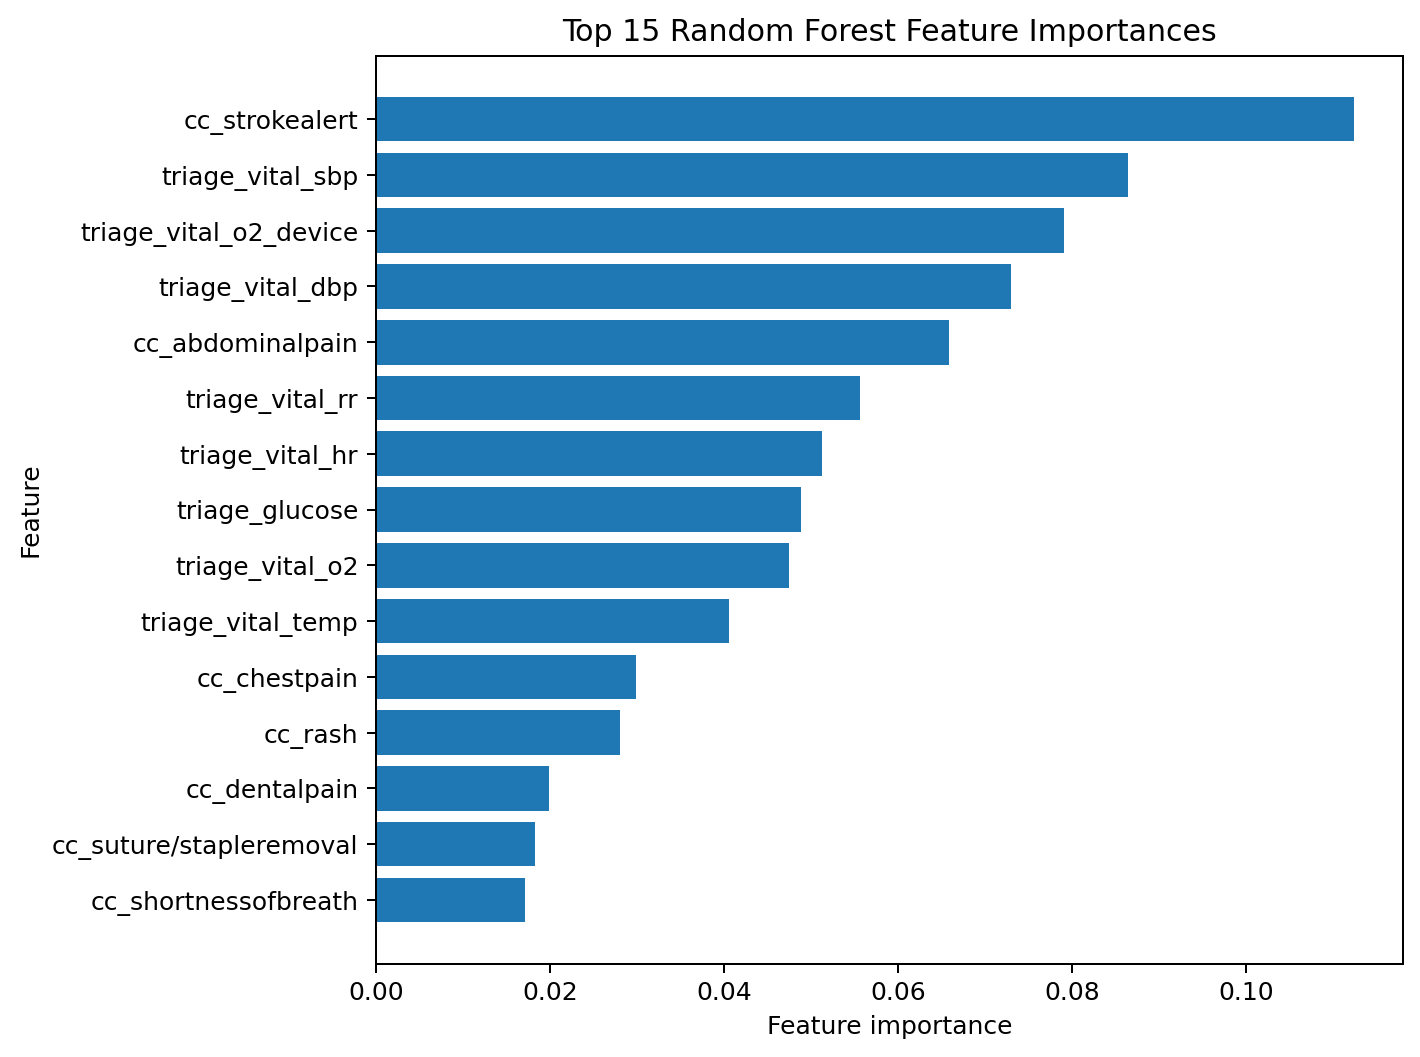

Feature,Importance
cc_strokealert,0.112440
triage_vital_sbp,0.086421
triage_vital_o2_device,0.079128
triage_vital_dbp,0.073019
cc_abdominalpain,0.065864
triage_vital_rr,0.055678
triage_vital_hr,0.051298
triage_glucose,0.048848
triage_vital_o2,0.047487
triage_vital_temp,0.040532


In [12]:
feature_importance = (
    pd.DataFrame(
        {
            "Feature": FEATURES,
            "Importance": random_forest.feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

top_features = feature_importance.head(15).sort_values(
    "Importance",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    top_features["Feature"],
    top_features["Importance"],
)
ax.set_title(
    "Top 15 Random Forest Feature Importances"
)
ax.set_xlabel("Feature importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

feature_importance.head(15)

## Interim conclusion

The complex model does not produce a simple overall win. It improves detection of the rarest critical class, but its overall accuracy and macro F1 are lower than logistic regression.

This creates the Week 7 engineering trade-off:

- **Benefit:** more ESI Level 1 patients are identified.
- **Cost:** more errors across the wider patient population.
- **Compute:** inference remains fast, but the forest contains 200 trees and is less straightforward to audit.
- **Interpretability:** global feature importance is available, but one patient-level prediction is harder to explain than a logistic-regression result or one tree.

The final submission should tune the complex model, inspect its critical errors and decide whether the extra ESI Level 1 detection justifies the loss in overall performance and interpretability.